<a href="https://colab.research.google.com/github/jben-hun/pyground/blob/master/notebooks/viterbi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pydot
import numpy as np
from IPython.display import Image

**Construct a hidden Markov model**

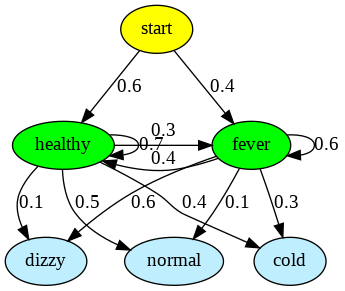

In [ ]:
sources = dict(
    start=dict(healthy=0.6, fever=0.4))
states = dict(
    healthy=dict(healthy=0.7, fever=0.3),
    fever=dict(healthy=0.4, fever=0.6))
sinks = dict(
    dizzy=dict(healthy=0.1, fever=0.6),
    cold=dict(healthy=0.4, fever=0.3),
    normal=dict(healthy=0.5, fever=0.1))

# visualization

G = pydot.Dot(graph_type="digraph")
for subgraph, color, dir, rank in (
    (sources, "yellow", "forward", "source"),
    (states, "green", "forward", "same"),
    (sinks, "lightblue1", "back", "sink")):
  S = pydot.Subgraph(rank=rank)
  for node1, nodes in subgraph.items():
    S.add_node(pydot.Node(node1, style="filled", fillcolor=color))
    for node2, p in nodes.items():
      G.add_edge(pydot.Edge(node1, node2, label=p, dir=dir))
  G.add_subgraph(S)

Image(G.create_png())

**Define Viterbi**

In [ ]:
def viterbi(sources, states, sinks, observations, show=False):
  K = len(states)
  N = len(sinks)
  T = len(observations)

  statesList = list(states) # shape (K)
  sinksList = list(sinks) # shape (N)

  Y = np.array([sinksList.index(o) for o in observations]) # shape (T)
  PI = np.array(tuple(sources["start"].values())) # shape (K)
  A = np.array([list(state.values()) for state in states.values()]) # shape (K, K)

  B = np.zeros((K, N))
  for i in range(K):
    for j in range(N):
      elementI = statesList[i]
      elementJ = sinksList[j]
      B[i, j] = sinks[elementJ][elementI] if elementI in sinks[elementJ] else 0

  T1 = np.zeros((K, T))
  T2 = np.zeros((K, T))
  
  # perform the dynamic programming algorithm

  T1[:, 0] = PI[:] * B[:, Y[0]]
  T2[:, 0] = 0
  for j in range(1, T):
    for i in range(K):
      T1[i, j] = np.max(T1[:, j-1] * A[:, i] * B[i, Y[j]])
      T2[i, j] = np.argmax(T1[:, j-1] * A[:, i])

  # extract result

  lastProbability = np.max(T1[:, -1])
  lastState = np.argmax(T1[:, -1])

  transition = [lastState]
  for j in range(T-1, 0, -1):
    transition.append(T2[int(transition[-1]), j])
  transition = transition[::-1]

  # visualization

  if show:
    G = pydot.Dot(graph_type="digraph", rankdir="LR")
    for i in range(K):
      G.add_edge(pydot.Edge("start", f"1. {statesList[i]}", label=PI[i],
                 color = "red" if i == transition[0] else "black"))
    for j in range(1, T):
      for i1 in range(K):
        for i2 in range(K):
          a = f"{j}. {statesList[i1]}"
          b = f"{j+1}. {statesList[i2]}"
          if int(T2[i2,j]) == i1:
            G.add_edge(pydot.Edge(
                a, b, label=T1[i2, j],
                color = "red" if i2 == transition[j] else "black"))
          else:
            G.add_edge(pydot.Edge(a, b, style="invis"))
    display(Image(G.create_png()))

  return dict(probability=lastProbability,
              transition=[statesList[int(r)] for r in transition])

**Run Viterbi**

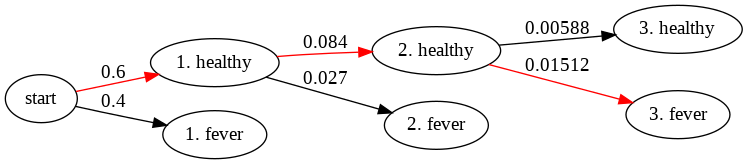

The most likely state transition with probability 0.01512 is: healthy >> healthy >> fever


In [ ]:
result = viterbi(sources=sources, states=states, sinks=sinks,
                 observations=("normal", "cold", "dizzy"), show=True)

print(f"The most likely state transition with probability {result['probability']} is: {' >> '.join(result['transition'])}")

**References**

*   <https://en.wikipedia.org/wiki/Viterbi_algorithm>
*   <https://networkx.github.io/documentation/stable/tutorial.html>
*   <https://github.com/nikhilkumarsingh/PyDot-Examples/blob/master/Directory_Structure_Plotter.ipynb>
*   <https://pypi.python.org/pypi/pydot>